In [ ]:
##Step 1 – Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
## Step 2 – Load Dataset
df = pd.read_csv("/content/synthetic_stock_data.csv")

print(df.head())
print(df.shape)
print(df.info())

         Date      Company      Sector        Open        High        Low  \
0  2022-01-01         Uber  Technology  100.000000  101.036120  97.477809   
1  2022-01-02        Tesla  Automotive  100.071106  102.037960  97.152675   
2  2022-01-03    Panasonic     Finance   99.857828  101.517497  98.108097   
3  2022-01-04      Tencent  Automotive   98.851663  101.303783  96.998218   
4  2022-01-05  Wells Fargo  Automotive   98.391118   99.990486  96.230707   

        Close  Volume    Market_Cap   PE_Ratio  Dividend_Yield  Volatility  \
0  100.000000  171958  5.156585e+11  24.253218        0.163090    0.047484   
1  100.071106  196867  9.755658e+11  18.602848        0.288515    0.022472   
2   99.857828  181932  4.595300e+11  10.728933        2.221827    0.019991   
3   98.851663  153694  5.577481e+11  14.582696        1.377740    0.036166   
4   98.391118  169879  8.607714e+11  37.491114        3.110198    0.034770   

   Sentiment_Score    Trend  
0         0.939232  Bearish  
1       

In [ ]:
## Step 3 – Convert Date
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

In [ ]:
## Step 4 – Check Missing Values
print(df.isnull().sum())
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.drop_duplicates(inplace=True)

Date               0
Company            0
Sector             0
Open               0
High               0
Low                0
Close              0
Volume             0
Market_Cap         0
PE_Ratio           0
Dividend_Yield     0
Volatility         0
Sentiment_Score    0
Trend              0
dtype: int64


In [ ]:
## Step 5 – Encode Categorical Variables
company_encoder = LabelEncoder()
sector_encoder = LabelEncoder()
trend_encoder = LabelEncoder()

df["Company"] = company_encoder.fit_transform(df["Company"])
df["Sector"] = sector_encoder.fit_transform(df["Sector"])
df["Trend"] = trend_encoder.fit_transform(df["Trend"])

In [ ]:
print(trend_encoder.classes_)

['Bearish' 'Bullish' 'Stable']


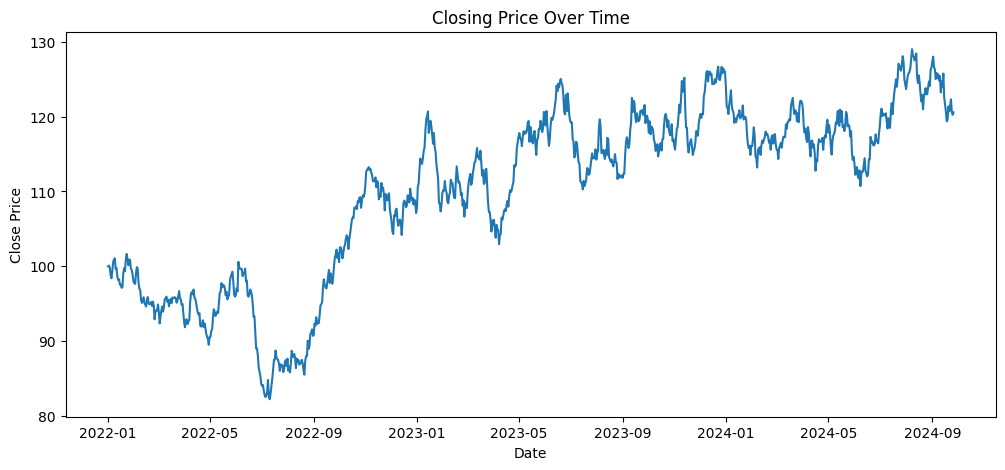

In [ ]:
## Step 6 – Exploratory Data Analysis
# 6.1 Closing Price Trend
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Close"])

plt.title("Closing Price Over Time")

plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

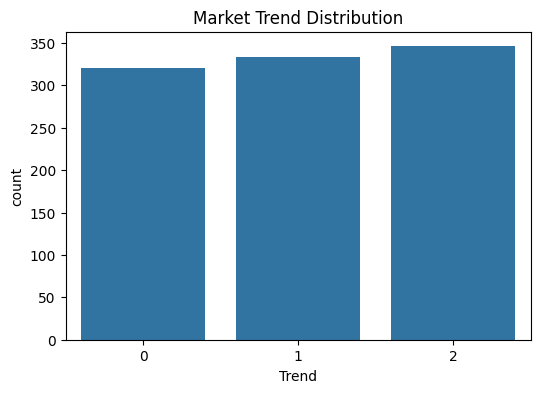

In [ ]:
#6.2 Trend Distribution
plt.figure(figsize=(6,4))

sns.countplot(x=df["Trend"])

plt.title("Market Trend Distribution")

plt.show()


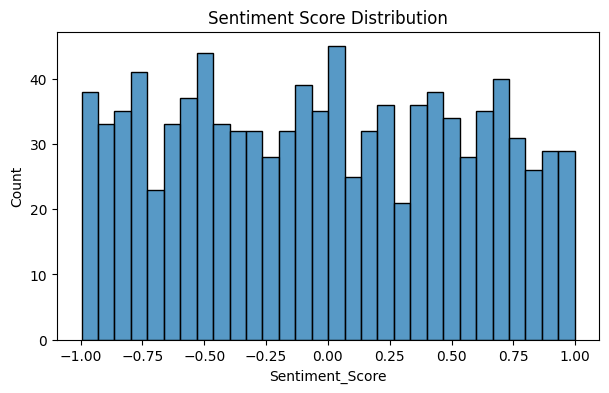

In [ ]:
#6.3 Sentiment Distribution
plt.figure(figsize=(7,4))

sns.histplot(df["Sentiment_Score"], bins=30)

plt.title("Sentiment Score Distribution")

plt.show()

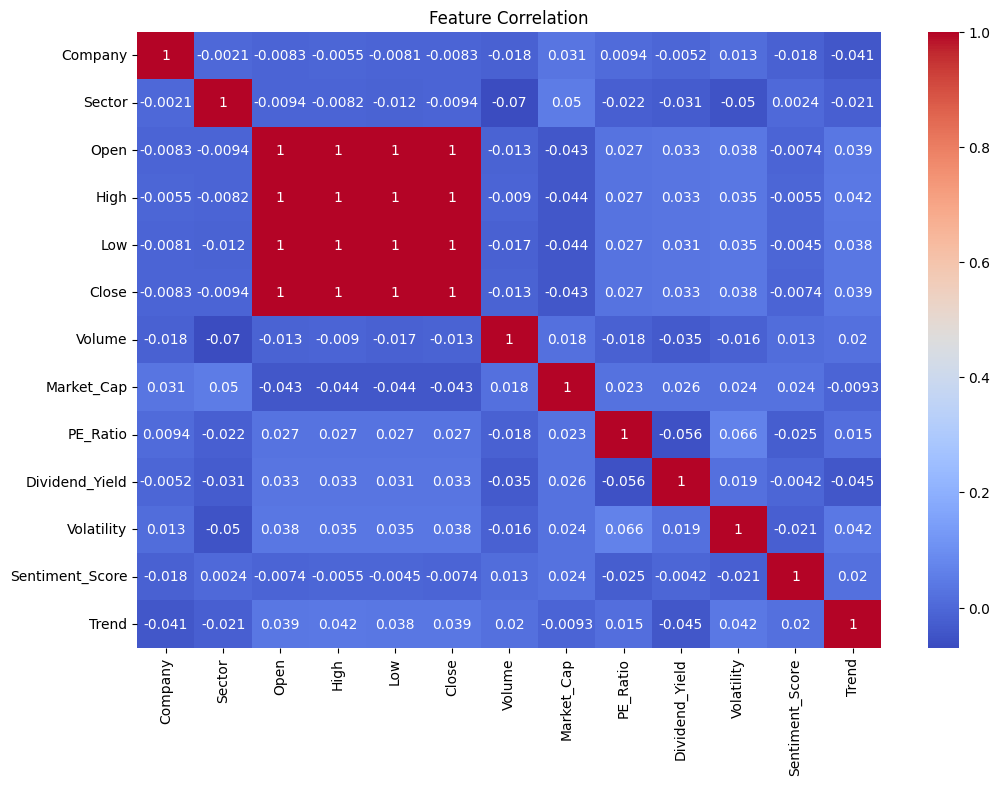

In [ ]:
#6.4 Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True
)

plt.title("Feature Correlation")

plt.show()

In [ ]:
##Step 7 – Feature Selection
#Baseline Model (Price Only)
price_features = [
    "Open",
    "High",
    "Low",
    "Close"
]

In [ ]:
#Hybrid Model
hybrid_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Market_Cap",
    "PE_Ratio",
    "Dividend_Yield",
    "Volatility",
    "Sentiment_Score"
]

In [ ]:
target = "Trend"

In [ ]:
##Step 8 – Scale Features
price_scaler = MinMaxScaler()
hybrid_scaler = MinMaxScaler()

price_scaled = price_scaler.fit_transform(df[price_features])

hybrid_scaled = hybrid_scaler.fit_transform(df[hybrid_features])

In [ ]:
y = df[target].values

In [ ]:
##Step 9 – Create Time Sequences
def create_sequences(X, y, window=10):

    X_seq = []
    y_seq = []

    for i in range(len(X)-window):

        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])

    return np.array(X_seq), np.array(y_seq)

window = 10

X_price, y_price = create_sequences(price_scaled, y, window)

X_hybrid, y_hybrid = create_sequences(hybrid_scaled, y, window)

In [ ]:
##Step 10 – Train/Test Split
split = int(len(X_price)*0.8)

X_price_train = X_price[:split]
X_price_test = X_price[split:]

X_hybrid_train = X_hybrid[:split]
X_hybrid_test = X_hybrid[split:]

y_train = y_price[:split]
y_test = y_price[split:]

In [ ]:
##Step 11 – Build LSTM Model
def build_lstm(input_shape):

    model = Sequential()

    model.add(
        LSTM(
            64,
            input_shape=input_shape
        )
    )

    model.add(Dropout(0.3))

    model.add(Dense(32, activation="relu"))

    model.add(Dense(3, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
##Step 12 – Train Price-only LSTM
price_model = build_lstm(
    (window, len(price_features))
)

history_price = price_model.fit(

    X_price_train,
    y_train,

    validation_split=0.2,

    epochs=30,

    batch_size=32,

    callbacks=[early_stop]
)

Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3349 - loss: 1.1026 - val_accuracy: 0.3459 - val_loss: 1.0977
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3144 - loss: 1.0999 - val_accuracy: 0.3459 - val_loss: 1.0952
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3712 - loss: 1.0986 - val_accuracy: 0.3648 - val_loss: 1.0947
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3270 - loss: 1.0989 - val_accuracy: 0.3648 - val_loss: 1.0950
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3318 - loss: 1.1005 - val_accuracy: 0.3459 - val_loss: 1.0984
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3333 - loss: 1.1042 - val_accuracy: 0.3648 - val_loss: 1.0940
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3602 - loss: 1.0998 - val_accuracy: 0.3459 - val_loss: 1.0956
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3491 - loss: 1.0995 - val_accuracy: 0.3459 - val_loss: 1.100

In [ ]:
##Step 13 – Train Hybrid LSTM
hybrid_model = build_lstm(
    (window, len(hybrid_features))
)

history_hybrid = hybrid_model.fit(

    X_hybrid_train,
    y_train,

    validation_split=0.2,

    epochs=30,

    batch_size=32,

    callbacks=[early_stop]
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3555 - loss: 1.1024 - val_accuracy: 0.3648 - val_loss: 1.0993
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3444 - loss: 1.1005 - val_accuracy: 0.3459 - val_loss: 1.1013
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3223 - loss: 1.0998 - val_accuracy: 0.3522 - val_loss: 1.0976
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3633 - loss: 1.0968 - val_accuracy: 0.3082 - val_loss: 1.0997
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3254 - loss: 1.0991 - val_accuracy: 0.3522 - val_loss: 1.1001


In [ ]:
##Step 14 – Predictions
#Price Model
price_prob = price_model.predict(X_price_test)

price_pred = np.argmax(price_prob, axis=1)

#Hybrid Model
hybrid_prob = hybrid_model.predict(X_hybrid_test)

hybrid_pred = np.argmax(hybrid_prob, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [ ]:
##Step 15 – Model Evaluation
def evaluate(actual, predicted, probability, model_name):

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    f1 = f1_score(
        actual,
        predicted,
        average="weighted"
    )

    accuracy = accuracy_score(
        actual,
        predicted
    )

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "F1": f1,
        "Accuracy": accuracy
    }

In [ ]:
price_results = evaluate(
    y_test,
    price_pred,
    price_prob,
    "Price LSTM"
)

hybrid_results = evaluate(
    y_test,
    hybrid_pred,
    hybrid_prob,
    "Hybrid LSTM"
)

results = pd.DataFrame([
    price_results,
    hybrid_results
])

print(results)

         Model      RMSE       MAE        F1  Accuracy
0   Price LSTM  1.201850  0.909091  0.189291  0.358586
1  Hybrid LSTM  1.191298  0.893939  0.218544  0.368687


In [ ]:
results.to_csv(
    "model_metrics.csv",
    index=False
)

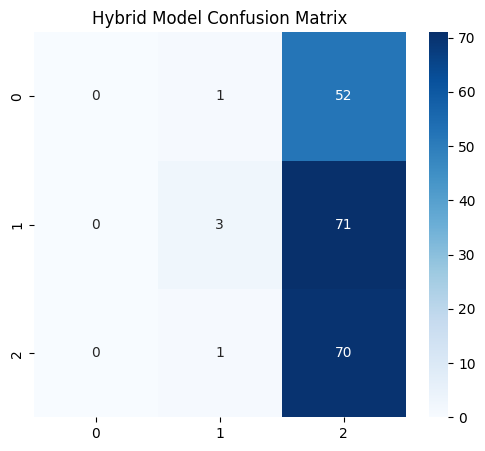

In [ ]:
##Step 16 – Confusion Matrix
cm = confusion_matrix(
    y_test,
    hybrid_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Hybrid Model Confusion Matrix")

plt.show()

In [ ]:
##Step 17 – Classification Report
print(
    classification_report(
        y_test,
        hybrid_pred,
        target_names=trend_encoder.classes_
    )
)

              precision    recall  f1-score   support

     Bearish       0.00      0.00      0.00        53
     Bullish       0.60      0.04      0.08        74
      Stable       0.36      0.99      0.53        71

    accuracy                           0.37       198
   macro avg       0.32      0.34      0.20       198
weighted avg       0.35      0.37      0.22       198



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


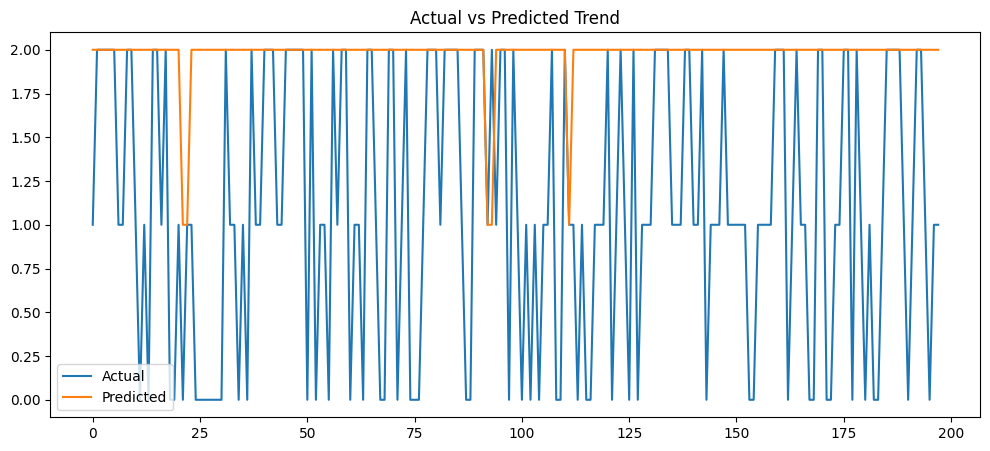

In [ ]:
## Step 18 – Actual vs Predicted Chart
plt.figure(figsize=(12,5))

plt.plot(
    y_test,
    label="Actual"
)

plt.plot(
    hybrid_pred,
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Trend")

plt.show()

In [ ]:
## Step 19 – Export Data for Power BI
prediction_df = pd.DataFrame({

    "Date": df["Date"].iloc[-len(y_test):].values,

    "Actual": trend_encoder.inverse_transform(y_test),

    "Predicted": trend_encoder.inverse_transform(hybrid_pred)

})

prediction_df.to_csv(
    "predictions.csv",
    index=False
)

In [ ]:
sentiment_summary = df.groupby("Trend")["Sentiment_Score"].mean().reset_index()

sentiment_summary["Trend"] = trend_encoder.inverse_transform(sentiment_summary["Trend"])

sentiment_summary.to_csv(
    "sentiment_summary.csv",
    index=False
)